# Igneous Segmentation Pipeline

**Purpose:** Processes a densely-reconstructed EM subvolume to extract per-cell segment IDs
and assign cell type labels. Uses the Igneous and CloudVolume libraries to access the
segmented volume and query which cells occupy defined spatial regions.

**Inputs:**
- VAST skeleton files (from `json_to_VASTskel.ipynb`) — defines the spatial bounding boxes
- `EM_data_published/data_processed_published/df_type_auto_typed.csv` — cell type assignments

**Outputs:**
- `EM_data_published/data_VAST/volume_subsample_sg-mg-out_ratio/df_segments_assigned.csv`

**Used by:** `Analyses_published.ipynb` (Spine Counts / Figure 2A section)

**Special requirements:**
- CloudVolume and Igneous must be installed: `pip install cloud-volume igneous`
- Mac/Linux only — CloudVolume does not support Windows
- Before running, start the local Igneous server in a terminal:
  ```
  cd EM_data_published/data_VAST/volume_subsample_sg-mg-out_ratio/
  igneous view precomputed_subvolume-apical-revision --port 8001
  ```

**Launch requirement:** Run `jupyter lab` from `efish_em/Notebooks_Jupyter/`

# Setup

In [1]:
import kimimaro
from cloudvolume import Skeleton
import os

import numpy as np
import kimimaro as km
import matplotlib.pyplot as plt
from PIL import Image
from pathlib import Path
import seaborn as sns
import imageio.v3 as iio
from scipy.io import loadmat
import h5py
from cloudvolume import CloudVolume 
import re
from tqdm import tqdm
import pandas as pd
import neuroglancer
import matplotlib.pyplot as plt
import matplotlib
from webbrowser import open as wb_open
from webbrowser import open_new as wb_open_new

from neuprint import skeleton as npskel
import networkx as nx


import sys
from pathlib import Path
DIR_ROOT = Path.cwd().parent / 'efish_em'
if str(DIR_ROOT) not in sys.path:
    sys.path.insert(0, str(DIR_ROOT))

# from eCREST_cli_beta import ecrest, import_settings
from eCREST_cli import ecrest
import AnalysisCode as efish 

## Plotting style settings

In [2]:
DIR_ROOT = Path.cwd().parent / 'efish_em'
filename = 'efish_em.mplstyle'
plt.style.use(DIR_ROOT / filename)

In [3]:
cell_colors = efish.color_palette('cell')
cell_colors['uk']='#aaaaaa'
cell_colors['fov']='#aaaaaa'
cell_colors['tsd']='#aaaaaa'
cell_colors['h']='#aaaaaa'
structure_colors = efish.color_palette('structure')

# mini tutorial video

https://www.youtube.com/watch?v=tyQGQtw2WIE

# VAST .raw SEG to cloudvolume precomputed

##  stack .raw to hdf5 numpy array dset

In [67]:
# Paths to VAST preprocessing data (set these to your local VAST data directory)
# These files are generated during VAST preprocessing, prior to the published dataset.
segpath = Path.cwd().parent.parent / 'EM_data_VAST' / 'segments' / 'subvolume'
skelpath = segpath.parent.parent / 'skeletons' / 'subvolume'
rawpath = Path.cwd().parent.parent / 'EM_data_VAST' / 'image_stacks'
h5path = Path.cwd().parent.parent / 'EM_data_VAST' / 'h5'

In [68]:
# cell_ids = ['386612701','386224676','299405462','299439953','299496636']#['299392199'] #mg1
# cell_ids = ['126649726','213605530','214581797','299404889','386426114']#,'387850816']#] # mg2


folder_list = ['subvolume_apical_revision']#[f'mg1_{c}_mip3_clipy' for c in cell_ids]#['SG_in-sub-vol_1-40_mip1','SG_in-sub-vol_41-89_mip1']#['386612701']]

In [70]:
bbox = loadmat(skelpath / 'boundingbox_all_revision.mat')['boundingbox']
#loadmat(segpath.parent.parent / 'skeletons/LG_presyn_labeled/lg_301787806_mip3_clipy_bbox.mat')['boundingbox']
# bbox[1][2] = 3535 # bbox[0][1] = 13000
# bbox[0][2] = 0
bbox

array([[ 9843,  1940,     0],
       [22520, 20235,  3535]], dtype=uint16)

In [71]:
rootstr = folder_list[0]
segpath / f'{rootstr}_ID.mat'

PosixPath('/Users/kperks/Library/CloudStorage/GoogleDrive-sawtelllab@gmail.com/My Drive/ELL_connectome/VAST/VAST_consolidate_reconstructed/segments/subvolume/subvolume_apical_revision_ID.mat')

In [72]:
for cell_folder in folder_list:
    rootstr = cell_folder #'_'.join(cell_folder.split('_')[0:3])#
    matarr = loadmat(segpath / f'{rootstr}_ID.mat')['name'] #loadmat(segpath / f'Fig1_gca_spines_lf_edited_ID.mat')['name']#
    ID = [int(n[0].split('_')[0]) for n in matarr[0][1:]]#[int(folder_list[0].split('_')[1])]#
    
    # Mapping dictionary
    ID_map = {i+1: n for i, n in enumerate(ID)}
    
    # Apply mapping while keeping zeros unchanged
    vectorized_map = np.vectorize(lambda x: ID_map.get(x, x))
    
    output_file = h5path / f'{cell_folder}.h5'
    dataset_name = "volume"
    
    # Dimensions and other parameters
    mip_level = 4
    VAST_res = [30,16,16]  #(nm/px) z,y,x 
    vox_res = (120,128,128) #(60,64,64)#(30,32,32)#(120,128,128)#(nm/px) z,y,x  # (nm/px) z,y,x 
    x_box = [bbox[0][0],bbox[1][0]]
    y_box = [bbox[0][1],bbox[1][1]]
    z_box = [bbox[0][2],bbox[1][2]]
    data_type = np.uint8
    
    fullpath = rawpath / cell_folder
    raw_files = sorted(Path(fullpath).glob("*.raw"))  # Ensure files are sorted correctly
    width = int(raw_files[0].name.split('_')[-2].split('x')[0])
    height = int(raw_files[0].name.split('_')[-2].split('x')[1])
    z_slices = len(raw_files)
        
    # Create the HDF5 file
    with h5py.File(output_file, "w") as hdf:
        # Create an empty dataset with the full dimensions
        dset = hdf.create_dataset(dataset_name, 
                                  shape=(z_slices, height, width), 
                                  dtype="uint32")
        
        # Write metadata
        dset.attrs["description"] = "3D volume data"
        dset.attrs["width"] = width
        dset.attrs["height"] = height
        dset.attrs["depth"] = z_slices
        dset.attrs["res"] = vox_res
        dset.attrs["offset"] = (np.min(z_box)*VAST_res[0]/vox_res[0], 
                                np.min(y_box)*VAST_res[1]/vox_res[1], 
                                np.min(x_box)*VAST_res[2]/vox_res[2])
        dset.attrs["order"] = ('z', 'y', 'x')
        dset.attrs["mip"] = mip_level
    
        # Process and write slices one at a time
        with tqdm(total=len(raw_files)) as pbar:
            for z, file_path in enumerate(raw_files):
                pbar.update(1)
                with open(file_path, "rb") as f:
                    slice_data = np.fromfile(f, dtype="uint8").reshape((height, width))
                    slice_data = slice_data.astype(np.int32)
                    slice_data = vectorized_map(slice_data)
                    dset[z, :, :] = slice_data  # Write directly to the HDF5 dataset

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 884/884 [07:15<00:00,  2.03it/s]


## combine h5 files

dset must be same size (same x,y,z bounds from VAST)

In [136]:
cell_ids = ['386612701','386224676','299405462','299439953','299496636'] #mg1
# cell_ids = ['126649726','213605530','214581797','299404889','386426114']# mg2
folder_list = [f'mg1_{cid}_mip3_clipy.h5' for cid in cell_ids]
folder_list

['mg1_386612701_mip3_clipy.h5',
 'mg1_386224676_mip3_clipy.h5',
 'mg1_299405462_mip3_clipy.h5',
 'mg1_299439953_mip3_clipy.h5',
 'mg1_299496636_mip3_clipy.h5']

In [137]:
input_files = [h5path / fname for fname in folder_list]#['MG_in-sub-vol_1-6.h5','MG_in-sub-vol_7-9.h5','MG_in-sub-vol_10-12.h5']]
output_file = h5path/ "MG1_presyn_annot.h5"

In [31]:
from contextlib import ExitStack

In [138]:

with ExitStack() as stack:
    h5_files = [stack.enter_context(h5py.File(f, 'r')) for f in input_files]  # Open all input files
    # print(h5_files[0].keys)
    
    with h5py.File(output_file, 'w') as f_out:  # Create a new HDF5 file
        for dset_name in h5_files[0].keys():  # Iterate through datasets
            # print(dset_name)
            data_shape = h5_files[0][dset_name].shape
            data_dtype = h5_files[0][dset_name].dtype
            
        # Create the dataset in the new file
        combined_data = f_out.create_dataset(dset_name, shape=data_shape, dtype=data_dtype)

        # Sum data from all input files
        combined_data[:] = sum(f[dset_name][()] for f in h5_files)

        # Copy attributes
        for attr_name, attr_value in h5_files[0][dset_name].attrs.items():
            combined_data.attrs[attr_name] = attr_value

In [166]:
# ID = []
# for cell_folder in ['SG_in-sub-vol_41-89','SG_in-sub-vol_1-40']:
#     matarr = loadmat(segpath / f'{cell_folder}_ID.mat')['name']
#     ID.extend([int(n[0].split('_')[0]) for n in matarr[0][1:]])

## read h5 file 

In [75]:
# Path to h5 files from VAST preprocessing
h5path = Path.cwd().parent.parent / 'EM_data_VAST' / 'h5'

In [76]:
cell_folder = 'subvolume_apical_revision'

In [77]:
# Define the file name and dataset name
hdf_file = h5path / f'{cell_folder}.h5'
# Open the HDF5 file in read mode
with h5py.File(hdf_file, "r") as hdf:
    # Access the dataset
    dset = hdf["volume"]
    print(dict(dset.attrs))
    
    volume = hdf["volume"][:]
    res = dset.attrs['res']
    order = dset.attrs['order']
    offset = dset.attrs['offset']


{'depth': 884, 'description': '3D volume data', 'height': 2287, 'mip': 4, 'offset': array([   0.   ,  242.5  , 1230.375]), 'order': array(['z', 'y', 'x'], dtype=object), 'res': array([120, 128, 128]), 'width': 1584}


## create precomputed using CloudVolume

### note can do with igneous

(ell-kimimaro) kperks@Kristas-Mac-mini VAST_to_ng % igneous image --help     
Usage: igneous image [OPTIONS] COMMAND [ARGS]...

  Manipulate image volumes. (subgroup)

  Images are the base datastructure in Neuroglancer. This subgroup offers
  methods for downsampling, transfers, reencoding, rechunking, sharding, and
  contrast correction.

Options:
  --help  Show this message and exit.

Commands:
  ccl         Perform connected components labeling on the image.
  contrast    Perform contrast correction on the image.
  create      Create a Precomputed volume from another data source.
  downsample  Create an image pyramid for grayscale or labeled images.
  reorder     Re-arrange z-slices.
  rm          Delete the image layer of a dataset.
  roi         Computes bounding box of non-empty image regions.
  voxels      Compute voxel counts per label.
  xfer        Copy, re-encode, or shard an image layer.
(ell-kimimaro) kperks@Kristas-Mac-mini VAST_to_ng % igneous image create --help
Usage: igneous image create [OPTIONS] SRC DEST

  Create a Precomputed volume from another data source.

  Supports: .npy files, .h5/.hdf5 files, and .ckl files

  Hopefully will support others such as TIFF in the future.

Options:
  --resolution TUPLE3        Resolution of the volume in nanometers along x,y,
                             and z dimensions.  [default: 1, 1, 1]
  --offset TUPLE3            Voxel offset in x,y, and z.  [default: 0, 0, 0]
  --seg                      Sets layer type to segmentation (default image).
  --encoding ENCODING        Which image encoding to use. Options: [all] raw,
                             png; [images] jpeg, jpegxl (jxl); [segmentations]
                             compressed_segmentation (cseg), compresso (cpso),
                             crackle (ckl); [floats] fpzip, kempressed, zfpc
                             [default: raw]
  --encoding-level TEXT      For some encodings (png level, jpeg & jpeg xl
                             quality, fpzip precision) a simple scalar value
                             can adjust the compression efficiency.
  --encoding-effort INTEGER  (JPEG XL) Set effort (1-10) used by JPEG XL to
                             hit the quality target.  [default: 5]
  --compress COMPRESS        Set the image compression scheme. Options:
                             'none', 'gzip', 'br'  [default: br]
  --chunk-size TUPLE3        Chunk size of new layers. e.g. 128,128,64
                             [default: 128, 128, 64]
  --h5-dataset TEXT          Which h5 dataset to acccess (hdf5 imports only).
                             [default: main]
  --help                     Show this message and exit.


In [81]:
# Define the output directory for the precomputed volume
output_dir = h5path.parent / f'precomputed/{cell_folder}'

axis_order = [np.where(order == axis)[0][0] for axis in ['x','y','z']]

# Create a CloudVolume object from the NumPy array
vol = CloudVolume.from_numpy(
    np.transpose(volume, axes=axis_order),#volume.T,
    vol_path=str(output_dir),
    voxel_offset=[offset[i] for i in axis_order],#(256,928, 64),
    resolution=[res[i] for i in axis_order],#(256, 256, 240),  # Example: 4x4x40 nm voxel size
    layer_type='segmentation',     # For image data; use 'segmentation' for label data
    max_mip=0
)

# # Save the volume
# vol.commit()  # Writes data to the specified directory
# print("Volume saved to:", output_dir)

# import raw EM from VAST into numpy array

from image_stacks folder, run `python stack_to_volume.py`

In [908]:
# Path to raw image stacks from VAST preprocessing
rawpath = Path.cwd().parent.parent / 'EM_data_VAST' / 'image_stacks'

cell_folder = 'EM_mip2'

In [909]:
fullpath = rawpath / cell_folder
raw_files = sorted(list(fullpath.glob('*.raw')))

In [380]:
# Define parameters
width = int(raw_files[0].name.split('_')[-2].split('x')[0])
height = int(raw_files[0].name.split('_')[-2].split('x')[1])
data_type = np.uint8

# Read all slices and stack into a 3D array
slices = []
for file_name in raw_files:
    file_path = rawpath / file_name
    with open(file_path, "rb") as f:
        slice_data = np.fromfile(f, dtype=data_type).reshape((height, width))
        
        slices.append(slice_data)

# Stack slices along the z-axis
volume = np.stack(slices, axis=0)

print(f'{volume.shape} in z,y,x')



(884, 4096, 4032) in z,y,x


## export volume to h5

part of `ptyhon stack_to_volume`

In [382]:
# Path to h5 files from VAST preprocessing
h5path = Path.cwd().parent.parent / 'EM_data_VAST' / 'h5'

In [383]:
x_box = [0]
y_box = [0]
z_box = [0]

vox_res = (60,64,64) #(nm/px) z,y,x

In [384]:
# Define the file name and dataset name
output_file = h5path / f'{cell_folder}.h5'
dataset_name = "volume"  # You can name the dataset as you like

with h5py.File(output_file, "w") as hdf:
    dset = hdf.create_dataset(dataset_name, data=volume)
    dset.attrs["description"] = "3D volume data"
    dset.attrs["width"] = volume.shape[2]
    dset.attrs["height"] = volume.shape[1]
    dset.attrs["depth"] = volume.shape[0]
    dset.attrs["res"] = vox_res # for mip4
    dset.attrs["offset"] =(np.min(z_box)*30/vox_res[0],np.min(y_box)*16/vox_res[1],np.min(x_box)*16/vox_res[2])
    dset.attrs["order"] = ('z','y','x')
    dset.attrs["mip"] = 2

print(f"Data saved to {output_file}")

Data saved to /Users/kperks/Library/CloudStorage/GoogleDrive-sawtelllab@gmail.com/My Drive/ELL_connectome/VAST/VAST_to_ng/h5/EM_mip3.h5


## read h5 file 

In [925]:
# Path to h5 files from VAST preprocessing
h5path = Path.cwd().parent.parent / 'EM_data_VAST' / 'h5'

In [926]:
cell_folder = 'EM_mip3'

In [922]:
# Define the file name and dataset name
hdf_file = h5path / f'{cell_folder}.h5'
# Open the HDF5 file in read mode
with h5py.File(hdf_file, "r") as hdf:
    # Access the dataset
    dset = hdf["volume"]
    print(dict(dset.attrs))
    volume = hdf["volume"][:]
    res = dset.attrs['res']
    order = dset.attrs['order']
    offset = dset.attrs['offset']


{'depth': 884, 'description': '3D volume data', 'height': 4096, 'mip': 3, 'offset': array([0., 0., 0.]), 'order': array(['z', 'y', 'x'], dtype=object), 'res': array([120, 128, 128]), 'width': 4032}


## create precomputed using CloudVolume

In [389]:
# Define the output directory for the precomputed volume
output_dir = h5path.parent / f'precomputed/{cell_folder}'

axis_order = [np.where(order == axis)[0][0] for axis in ['x','y','z']]

# Create a CloudVolume object from the NumPy array
vol = CloudVolume.from_numpy(
    volume.T,
    vol_path=str(output_dir),
    voxel_offset=[offset[i] for i in axis_order],#(256,928, 64),
    resolution=[res[i] for i in axis_order],#(256, 256, 240),  # Example: 4x4x40 nm voxel size
    layer_type='image',     # For image data; use 'segmentation' for label data
    max_mip=0
)

# # Save the volume
# vol.commit()  # Writes data to the specified directory
# print("Volume saved to:", output_dir)

### CHUNKED

In [3]:
# Path to h5 files from VAST preprocessing
h5path = Path.cwd().parent.parent / 'EM_data_VAST' / 'h5'

In [4]:
cell_folder = 'EM_mip2'

In [8]:
hdf_file = h5path / f'{cell_folder}.h5'
chunk_depth = 10  # Number of slices to process at a time
# z_slices, height, width = dset.shape

with h5py.File(hdf_file, "r") as hdf:
    dset = hdf["volume"]
    print(dset.shape)
    z_slices, height, width = dset.shape
    res = dset.attrs["res"]
    order = dset.attrs["order"]
    offset = dset.attrs["offset"]

    axis_order = [np.where(order == axis)[0][0] for axis in ["x", "y", "z"]]

    # Define the output directory
    output_dir = h5path.parent / f"precomputed/{cell_folder}"
    vol = CloudVolume.from_numpy(
        np.zeros((width, height, z_slices), dtype="uint8"),  # Initialize metadata
        vol_path=str(output_dir),
        voxel_offset=[offset[i] for i in axis_order],
        resolution=[res[i] for i in axis_order],
        layer_type="image",  # Use 'segmentation' for label data
        max_mip=0,
        compress=True
    )

(992, 8192, 8064)


In [ ]:
with h5py.File(hdf_file, "r") as hdf:
    dset = hdf["volume"]
    print(dset.shape)
    z_slices, height, width = dset.shape
    res = dset.attrs["res"]
    order = dset.attrs["order"]
    offset = dset.attrs["offset"]

    axis_order = [np.where(order == axis)[0][0] for axis in ["x", "y", "z"]]
    # Write data in chunks
    # z_slices=50
    for z_start in range(0, z_slices, chunk_depth): #
        z_end = min(z_start + chunk_depth, z_slices)  # Ensure the last chunk fits
        
        print(f"Processing slices {z_start} to {z_end - 1}")

        # Read chunk from HDF5
        chunk = dset[z_start:z_end, :, :]
        print(chunk.shape)

        # Transpose to Neuroglancer format (x, y, z)
        chunk = np.transpose(chunk, axes=(2, 1, 0))

        # Write chunk to Neuroglancer
        vol[
            :, :, z_start:z_end
        ] = chunk #.T  # Transpose to Neuroglancer's (x, y, z) order

# Command line tasks

## queue

In [ ]:
# pqt status ./queue # checks status of queue

# igneous execute -x ./queue # -x flag exits when done with all tasks

## downsampling

In [ ]:
# igneous image downsample ./precomputed/test_em --queue ./queue # run from VAST_to_ng folder; creates queue directory in VAST_to_ng folder if does not exist)



## mesh

---
igneous mesh --help  
Usage: igneous mesh [OPTIONS] COMMAND [ARGS]...  
  
  Create 3D meshes from a segmentation. (subgroup)  
  
  Meshing is a two step process of forging then  merging. First the meshes are
  created from a regular grid of segmentation cutouts. Second, the pieces are
  glued together.  
  
Options:  
  --help  Show this message and exit.  
  
Commands:  
  **clean**          Removes temporary files.  
  **forge**          (1) Synthesize meshes from segmentation cutouts.  
  **merge**          (2) Merge the mesh pieces produced from the forging step.  
  **merge-sharded**  (2) Postprocess fragments into finished sharded multires...  
  **rm**             Delete mesh files.  
  **spatial-index**  (subgroup) Create or download mesh spatial indices.  
  **xfer**           Transfer meshes to another location.  

---

Two-step process: first forge (creates mesh for each section of the image -- marching cubes simplification with edges set up for merge), second merge ()

In [ ]:
# igneous mesh forge [cell_folder] --mip 0 --queue ./queue
# igneous execute -x ./queue    
# igneous mesh merge sg2_387415866_crude_mip3 --queue ./queue
# igneous execute -x ./queue    

## skeleton

igneous skeleton --help    
Usage: igneous skeleton [OPTIONS] COMMAND [ARGS]...  

  Create skeletons from a segmentation.  
 
  Skeletonizing is a two step process of forging  then merging. First the
  skeletons are created from a regular grid of segmentation cutouts. Second,
  the pieces are postprocessed and glued together.  

Options:  
  --help  Show this message and exit.  

Commands:  
  **clean**          Removes temporary files.  
  **forge**          (1) Synthesize skeletons from segmentation cutouts.  
  **merge**          (2) Postprocess fragments into finished skeletons.  
  **merge-sharded**  (2) Postprocess fragments into finished skeletons.  
  **rm**             Delete skeleton files.  
  **spatial-index**  (subgroup) Create or download mesh spatial indices.  
  **xfer**           Transfer skeletons to another location.  

igneous skeleton forge --help  
Usage: igneous skeleton forge [OPTIONS] PATH  

  (1) Synthesize skeletons from segmentation cutouts.  

  A large labeled image is divided into a regular grid. Kimimaro is applied to
  grid point, which performs a TEASAR based skeletonization.  

  You can read more about the parameters here: https://github.com/seung-lab/kimimaro  

  Tutorials are located here:  

  - https://github.com/seung-lab/kimimaro/wiki/A-Pictorial-Guide-to-TEASAR-Skeletonization  

  - https://github.com/seung-lab/kimimaro/wiki/Intuition-for-Setting-Parameters-const-and-scale  

  A guide to how much this might cost is located here:  
 
  - https://github.com/seung-lab/kimimaro/wiki/The-Economics:-Skeletons-for-the-People  

Options:  
  --queue TEXT                    AWS SQS queue or directory to be used for atask queue. e.g. sqs://my-queue or ./my-queue. See https://github.com/seung-lab/python-task-queue  
  --mip INTEGER                   Perform skeletonizing using this level of
                                  the image pyramid.  [default: 0]  
  --shape TUPLE3                  Set the task shape in voxels.  [default:
                                  512, 512, 512]  
  --fill-missing                  Interpret missing image files as background
                                  instead of failing.  
  --fix-branching                 Trades speed for quality of branching at
                                  forks.  [default: True]  
  --fix-borders                   Allows trivial merging of single voxel
                                  overlap tasks. Only switch off for datasets
                                  that fit in a single task.  [default: True]  
  --fix-avocados                  Fixes somata where nuclei and cytoplasm have
                                  separate segmentations.  
  --fix-autapses                  (graphene only) Fixes autapses by using the
                                  PyChunkGraph.  
  --fill-holes                    Preprocess each cutout to eliminate
                                  background holes and holes caused by
                                  entirely contained inclusions. Warning: May
                                  remove labels that are considered
                                  inclusions.  
  --dust-threshold INTEGER        Skip skeletonizing objects smaller than this
                                  number of voxels within a cutout.  [default:
                                  1000]  
  --dust-global / --dust-local    Use global voxel counts for the dust
                                  threshold (when >0). To use this feature you
                                  must first compute the global voxel counts
                                  using the `igneous image voxels` command.
                                  [default: dust-local]    
  --spatial-index / --skip-spatial-index
                                  Create the spatial index.  [default:
                                  spatial-index]  
  --scale FLOAT                   Multiplies invalidation radius by distance
                                  from boundary.  [default: 4]  
  --const FLOAT                   Adds constant amount to invalidation radius
                                  in physical units.  [default: 10]  
  --soma-detect FLOAT             Consider objects with peak distances to
                                  boundary larger than this soma candidates.
                                  Physical units.  [default: 1100]  
  --soma-accept FLOAT             Accept soma candidates over this threshold
                                  and perform a one-time spherical
                                  invalidation around their peak value.
                                  Physical units.  [default: 3500]  
  --soma-scale FLOAT              Scale factor for soma invalidation.
                                  [default: 1.0]  
  --soma-const FLOAT              Const factor for soma invalidation.
                                  [default: 300]  
  --max-paths FLOAT               Abort skeletonizing an object after this
                                  many paths have been traced.  
  --sharded                       Generate shard fragments instead of
                                  outputing skeleton fragments.  
  --labels TUPLEN                 Skeletonize only this comma separated list
                                  of labels.  
  --cross-section INTEGER         Compute the cross sectional area for each
                                  skeleton vertex. May add substantial
                                  computation time. Integer value is the
                                  normal vector rolling average smoothing
                                  window over vertices. 0 means off.
                                  [default: 0]  
  -o, --output CLOUDPATH          Output the results to a different place.  
  --timestamp INTEGER             (graphene) Use the proofreading state at
                                  this UNIX timestamp.  
  --root-ids CLOUDPATH            (graphene) If you have a materialization of
                                  graphene root ids for this timepoint, it's
                                  more efficient to use it than making
                                  requests to the graphene server.  
  --help                          Show this message and exit.  


igneous skeleton forge [cell_folder] --mip 0 --queue ./queue

with parameters for TEASER tweaked

igneous skeleton forge MG2_presyn_annot --mip 0 --scale 25 --const 5 --soma-scale 3 --soma-detect 3000 --soma-accept 4500 --queue ./queue
igneous skeleton forge MG1_presyn_annot --mip 0 --scale 25 --const 5 --soma-scale 3 --soma-detect 3000 --soma-accept 4500 --queue ./queue

igneous skeleton forge sg2_387415866_crude_mip3 --mip 0 --dust-threshold 250 --scale 10 --const 50 --soma-scale 3 --soma-detect 3000 --soma-accept 5000 --queue ./queue
igneous skeleton forge sg2_387415866_crude_mip3 --mip 0 --scale 10 --const 50 --soma-scale 5 --soma-detect 5000 --soma-accept 7000 --queue ./queue

--mip 0 --dust-threshold 250 --scale 50 --const 100 --soma-scale 3 --soma-detect 3000 --soma-accept 4500 --queue ./queue

igneous execute -x ./queue   
igneous skeleton merge sg2_387415866_crude_mip3 --queue ./queue
igneous execute -x ./queue   

In [71]:
# igneous skeleton merge [cell_folder] --queue ./queue

# CloudVolume precomputed to swc

In [175]:
vol = CloudVolume('precomputed://http://localhost:8001')

In [176]:
segIDs_all = vol.unique(bbox=vol.bounds) - set([0]) # get all segment IDs in volume and remove segment ID 0, which is background

Downloading: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 595/595 [00:03<00:00, 182.47it/s]


In [208]:
cid = 386612701
skel = vol.skeleton.get(cid)#(301787806)#(299405462)#(393325331)
# ['299392199','299405462']


## view skeleton

In [145]:
%matplotlib widget

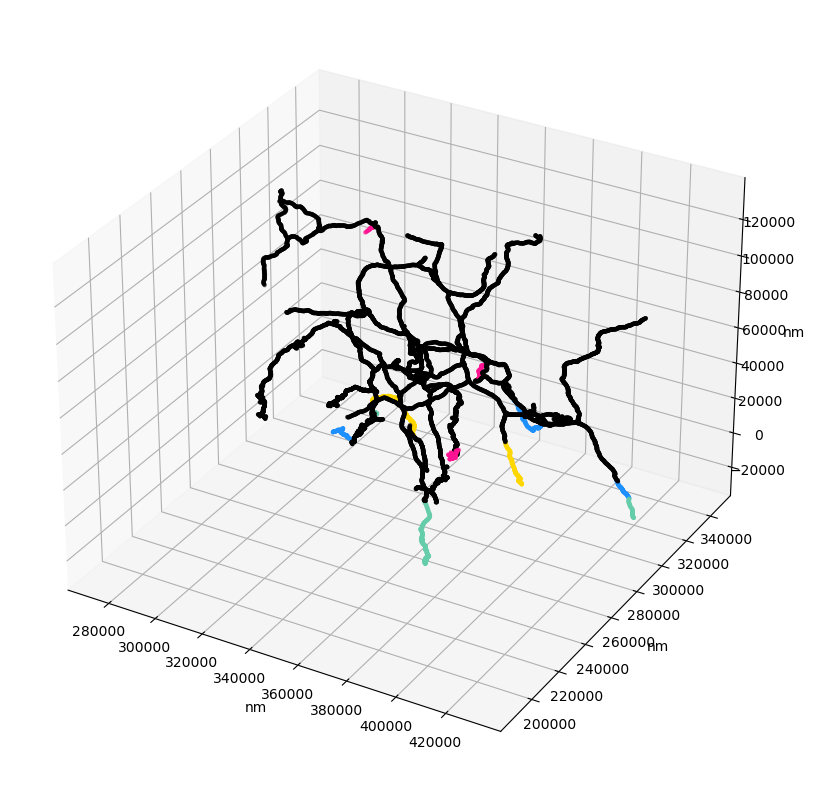

In [209]:
# skel.viewer(draw_edges=False)#(color_by='component',draw_edges=False)
skel.viewer(color_by='component',draw_edges=False)

## merge skeleton components using kimimaro

In [101]:
skel_merged = kimimaro.join_close_components(skel.components(), radius=1500)

## use only the one largest component from skel

In [210]:
maxind = np.argmax([len(c.vertices) for c in skel.components()])

In [211]:
skel = skel.components()[maxind]

## use multiple hand-picked components from skel

In [128]:
skel = skel.components()[0].merge(skel.components()[2])

In [16]:
# for i, skel in enumerate(skel.components()):
#   with open(str(swc_outfile / str(skel.id)) + '-' + str(i) + '.swc', 'wt') as f:
#     f.write(skel.to_swc())

## export skeleton to swc

In [191]:
# Path to SWC output directory (from VAST preprocessing)
swc_outfile = Path.cwd().parent.parent / 'EM_data_VAST' / 'swc'

In [213]:
cell_folder = f'mg2_{cid}_mip3_clipy'  # update cell type and ID as needed

'mg2_386612701_mip3_clipy'

In [214]:
# Step 4: Write the SWC data to a file
with open(swc_outfile / f'{cell_folder}.swc', 'w') as swc_file:
    swc_file.write(skel.to_swc())

# Apical Branch Length

In [83]:
DATA_ROOT = Path.cwd().parent.parent / 'EM_data_published'
folder_path = DATA_ROOT / 'data_VAST' / 'volume_subsample_sg-mg-out_ratio'
df_segments = pd.read_csv(folder_path / 'df_segments_assigned.csv')

In [11]:
DATA_ROOT = Path.cwd().parent.parent / 'EM_data_published'
dirpath = DATA_ROOT / 'data_processed_published'
df_type= pd.read_csv(dirpath / 'df_type_auto_typed.csv')

In [10]:
'SG_in-sub-vol'
'MG_in-sub-vol'
'OUTPUT_in-sub-vol'

'OUTPUT_in-sub-vol'

In [85]:
def create_bins(boundaries):
    bins = []
    for i in range(len(boundaries) - 1):
        bins.append((boundaries[i], boundaries[i + 1]))
    return bins
    

In [86]:
vol = CloudVolume('precomputed://http://localhost:8001',progress=False)

In [87]:
# HOW GET NUMBER OF SEGMENTS IN PRECOMPUTED TO LOOP THROUGH THEM?

In [88]:
segIDs_all = vol.unique(bbox=vol.bounds) - set([0]) # get all segment IDs in volume and remove segment ID 0, which is background

In [89]:
seglist = list(segIDs_all)

In [18]:
# spd = density_out

In [91]:
df_result= pd.DataFrame()

# seglist = [386392158,213590737]# MG 
# seglist = list(segIDs_all)
# seglist = [128879866,214627855,128849661] # mature SG
# seglist = [4,2,6]

mol_bounds = [1000, 3000, 5000, 7000, 9000, 12000,14000]
bins = create_bins(mol_bounds)


for seg in seglist:
    skel = vol.skeleton.get(seg)
    
    swc = skel.to_swc()
    
    df = npskel.skeleton_swc_to_df(swc)
    
    # change positions to 16nm segmentation scale(because that is the resolution in which y positions are marked)
    df['y'] = -(df['y']/16 - (16210)) # offset y position like do for spine density analysis
    df['x'] = df['x']/16
    df['z'] = df['z']/30
    vox_to_nm = 16 # to transform distance back into nm later
    
    d_total = []
    sp_total = []
    for i,b in enumerate(bins):
        mask = (df['y']>b[0]) & (df['y']<b[1])
        G = npskel.skeleton_df_to_nx(df[mask], with_attributes=True, directed=True, with_distances=True, virtual_roots=True)
        distance=nx.get_edge_attributes(G,'distance')
        d_total.append(sum(filter(lambda x: x != float('inf'), np.asarray(list(distance.values()))))*vox_to_nm/1000)
        # sp_total.append(d_total[i]*spd[i])

    df_ = pd.DataFrame({
        'depth' : bins,
        'labels' : ['d0', 'd1', 'd2', 'd3', 'd4','d5'],
        'dx_total' : d_total
        # 'sp_total' : sp_total
        # 'seg' : seg        
    })
    df_['seg']=seg
    df_['ctype'] = df_type[df_type['id'].isin([seg])]['cell_type'].values[0]
    df_result = pd.concat([df_result,df_],ignore_index=True)

In [92]:
df_result.loc[df_result['ctype'].isin(['sg1','sg2']),'class'] = 'sg'
df_result.loc[df_result['ctype'].isin(['mg1','mg2']),'class'] = 'mg'
df_result.loc[df_result['ctype'].isin(['lg','lf']),'class'] = 'output'

In [94]:
density_sg = np.asarray([20,20,20,20,20,20])/10
density_mg = np.asarray([53.000000,95.647059,113.352941,113.388889,88.187500,50.958333])/10
density_out = np.asarray([38.647059,55.360000,64.944444,74.555556,63.800000,70.000000])/10

# Map depth labels to density indices
depth_order = ['d0','d1','d2','d3','d4','d5']#[
#     (1000, 3000),
#     (3000, 5000),
#     (5000, 7000),
#     (7000, 9000),
#     (9000, 12000),
#     (12000, 14000)
# ]


# Create lookup dictionary for each class
density_lookup = {
    'sg': dict(zip(depth_order, density_sg)),
    'mg': dict(zip(depth_order, density_mg)),
    'output': dict(zip(depth_order, density_out))
}

In [95]:
# Function to get density for each row
def get_density(row):
    return density_lookup[row['class']][row['labels']]

# Apply and compute sp_total
df_result['sp_density'] = df_result.apply(get_density, axis=1)
df_result['sp_total'] = df_result['dx_total'] * df_result['sp_density']

In [97]:
df_result.to_csv(folder_path / 'df_spine_estimates_sg_mg_out.csv')